# QAOA 教程：MaxCut 问题 + VQE 对比

本教程涵盖：
1. **顶层调用**：使用 `QAOARunner.run_model` 统一接口求解 MaxCut
2. **手动拆解**：理解 QAOA ansatz 线路结构
3. **可视化**：优化收敛曲线、概率分布、最优切割方案
4. **与 VQE 对比**：cost 收敛 + 期望值对比

默认用 `Simulator`，便于稳定复现与快速实验。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from quantum_hw import QuantumHardwareClient, QuantumCircuit
from quantum_hw.algorithms.qaoa import (
    QAOARunner,
    build_maxcut_hamiltonian,
    build_qaoa_ansatz_symbolic,
)
from quantum_hw.algorithms.optimizer_utils import instantiate_transpiled_template
from quantum_hw.algorithms.vqe import VQERunner, build_custom_hamiltonian
from quantum_hw.api.backend import Backend

def section(title: str):
    print("\n" + "=" * 18, title, "=" * 18)

## 1) 定义 MaxCut 问题的图结构

构建一个 4 节点 5 边的无向图，加权边表示节点间的连接关系。


================== Graph definition ==================


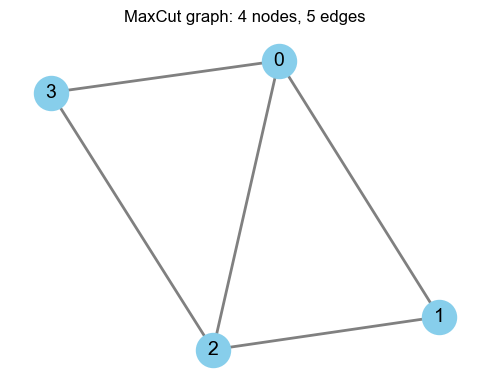

In [2]:
section("Graph definition")

num_qubits = 4
edges = [(0, 1), (1, 2), (2, 3), (0, 3), (0, 2)]

# 可视化图结构
try:
    import networkx as nx
    G = nx.Graph()
    G.add_nodes_from(range(num_qubits))
    G.add_edges_from(edges)
    pos = nx.spring_layout(G, seed=42)
    fig, ax = plt.subplots(figsize=(5, 4))
    nx.draw(G, pos, ax=ax, with_labels=True, node_color="skyblue",
            node_size=600, font_size=14, edge_color="gray", width=2)
    ax.set_title(f"MaxCut graph: {num_qubits} nodes, {len(edges)} edges")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("networkx not installed, skipping graph visualization")
    print(f"nodes: {list(range(num_qubits))}")
    print(f"edges: {edges}")

## 2) 构建 MaxCut 代价哈密顿量

MaxCut 哈密顿量为：
$$H_C = \sum_{(i,j) \in E} \frac{1}{2}(I - Z_i Z_j)$$

我们只保留 ZZ 项（常数偏移不影响优化）：$H = \sum_{(i,j)} +\frac{1}{2} Z_i Z_j$

最小化 $\langle H \rangle$ 使相邻比特倾向于反平行（$Z_i Z_j = -1$），对应最大切割。

In [3]:
section("Hamiltonian")

hamiltonian = build_maxcut_hamiltonian(edges, num_qubits)
print(f"MaxCut hamiltonian ({len(hamiltonian)} terms):")
for coeff, pauli in hamiltonian:
    print(f"  {coeff:+.2f} * {pauli}")


================== Hamiltonian ==================
MaxCut hamiltonian (5 terms):
  +0.50 * ZZII
  +0.50 * IZZI
  +0.50 * IIZZ
  +0.50 * ZIIZ
  +0.50 * ZIZI


## 3) 配置参数与顶层调用：QAOARunner.run_model

使用统一的 `run_model()` 接口，自动构建 MaxCut 哈密顿量并运行优化。

In [51]:
section("high-level QAOA (autograd)")

p = 2           # QAOA 层数
shots = 2048
max_iters = 30
learning_rate = 0.3
seed = 42

client = QuantumHardwareClient()
qaoa = QAOARunner(
    client=client,
    p=p,
    shots=shots,
    max_iters=max_iters,
    learning_rate=learning_rate,
    seed=seed,
    gradient_method="autograd",  # Simulator 上用 autograd 收敛快
)

result_qaoa = qaoa.run_model(
    name="demo_qaoa_maxcut",
    num_qubits=num_qubits,
    edges=edges,
    prefer_chips="Simulator",
)

print(f"best_cost:   {result_qaoa.best_cost:.6f}")
print(f"best_params: {[f'{v:.4f}' for v in result_qaoa.best_params]}")
print(f"iters:       {len(result_qaoa.cost_history)}")


================== high-level QAOA (autograd) ==================
[qaoa] prepare run: name=demo_qaoa_maxcut num_qubits=4 provider=quafu p=2 shots=2048 max_iters=30
[qaoa] candidate chips: ['Simulator']
[qaoa] running on chip: Simulator
[qaoa] start optimization: p=2 params=4 iters=30 shots=2048 gradient=autograd
[qaoa] iter 0 cost=-0.070310 grad_norm=2.697690
[qaoa] iter 0 new best=-0.070310
[qaoa] iter 1 cost=-0.130727 grad_norm=1.148038
[qaoa] iter 1 new best=-0.130727
[qaoa] iter 2 cost=0.011686 grad_norm=0.555239
[qaoa] iter 3 cost=0.022624 grad_norm=0.389799
[qaoa] iter 4 cost=-0.030186 grad_norm=0.762980
[qaoa] iter 5 cost=-0.216074 grad_norm=1.273470
[qaoa] iter 5 new best=-0.216074
[qaoa] iter 6 cost=-0.472064 grad_norm=0.707263
[qaoa] iter 6 new best=-0.472064
[qaoa] iter 7 cost=-0.424152 grad_norm=0.941515
[qaoa] iter 8 cost=-0.314240 grad_norm=1.302938
[qaoa] iter 9 cost=-0.355414 grad_norm=1.406679
[qaoa] iter 10 cost=-0.536431 grad_norm=1.208412
[qaoa] iter 10 new best=-0.

## 4) 可视化优化收敛过程

绘制 cost 随迭代变化的曲线，以及 $\gamma$/$\beta$ 参数轨迹。

C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\740223238.py:22: UserWarning: Glyph 10216 (\N{MATHEMATICAL LEFT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\740223238.py:22: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()


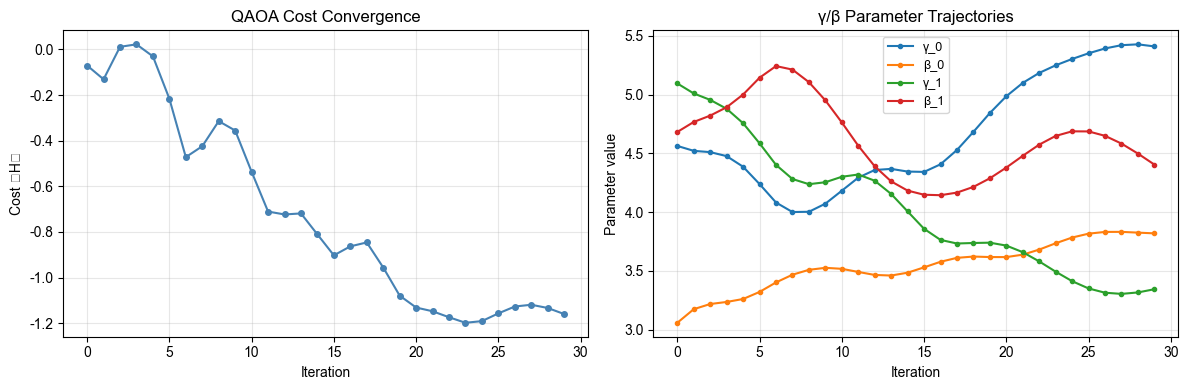

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cost convergence
axes[0].plot(result_qaoa.cost_history, "o-", ms=4, color="steelblue")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Cost ⟨H⟩")
axes[0].set_title("QAOA Cost Convergence")
axes[0].grid(alpha=0.3)

# Parameter trajectories
if result_qaoa.params_history:
    params_arr = np.array(result_qaoa.params_history)
    for i in range(params_arr.shape[1]):
        label = f"γ_{i//2}" if i % 2 == 0 else f"β_{i//2}"
        axes[1].plot(params_arr[:, i], "o-", ms=3, label=label)
    axes[1].set_xlabel("Iteration")
    axes[1].set_ylabel("Parameter value")
    axes[1].set_title("γ/β Parameter Trajectories")
    axes[1].legend(fontsize=9)
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 5) 解码最优解 & 概率分布

利用最优参数构建 QAOA 线路，通过模拟器采样获取概率分布，找出最大概率的比特串（即 MaxCut 近似解）。


================== Decode solution ==================
Top-8 most probable bitstrings:
  |1010⟩  prob=0.4203  cut=4
  |0101⟩  prob=0.4188  cut=4


C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\3438193338.py:43: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()


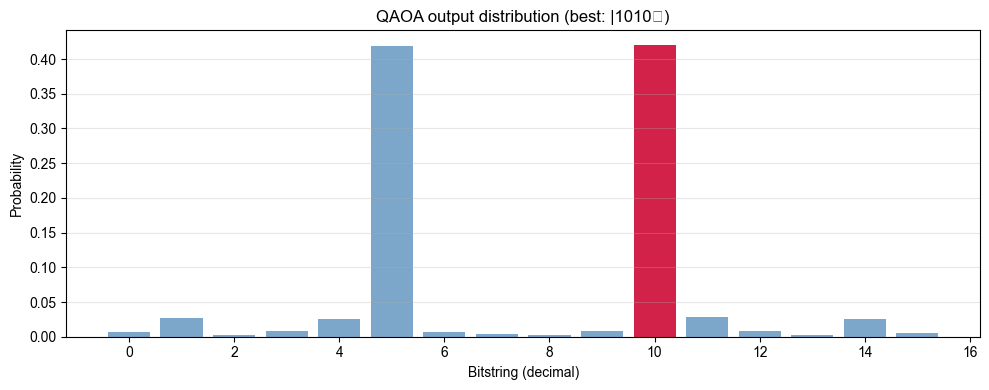

In [53]:
section("Decode solution")

# 用最优参数重建线路并运行获取概率
best_params = result_qaoa.best_params
param_names, symbolic_qc = build_qaoa_ansatz_symbolic(num_qubits, edges, p)
# param_names 顺序为交替排列: [gamma_0, beta_0, gamma_1, beta_1, ...]

qc_params = instantiate_transpiled_template(symbolic_qc, param_names, best_params)
result_run = client._run_with_backend(
    qc_params,
    "decode",
    num_qubits,
    backend=Backend("Simulator"),
    chip_name="Simulator",
    shots=8192,
    transpile=True,
    return_probabilities=True,
)

probs = result_run.probabilities[0] if result_run.probabilities else []
if probs:
    n_states = len(probs)
    bitstrings = [format(i, f"0{num_qubits}b") for i in range(n_states)]
    top_k = sorted(range(n_states), key=lambda i: probs[i], reverse=True)[:2]

    print("Top-8 most probable bitstrings:")
    for idx in top_k:
        # 计算该 bitstring 的 cut 值
        bits = [int(b) for b in bitstrings[idx]]
        cut = sum(1 for i, j in edges if bits[i] != bits[j])
        print(f"  |{bitstrings[idx]}⟩  prob={probs[idx]:.4f}  cut={cut}")

    # 概率分布直方图
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(range(n_states), probs, color="steelblue", alpha=0.7)
    # 高亮最优
    best_idx = top_k[0]
    ax.bar(best_idx, probs[best_idx], color="crimson", alpha=0.9)
    ax.set_xlabel("Bitstring (decimal)")
    ax.set_ylabel("Probability")
    ax.set_title(f"QAOA output distribution (best: |{bitstrings[best_idx]}⟩)")
    ax.grid(alpha=0.3, axis="y")
    plt.tight_layout()
    plt.show()
else:
    print("No probabilities returned")

## 6) QAOA vs VQE 对比

在同一代价函数上分别用 QAOA 和 VQE 求解，观察两者的收敛行为差异。

- **QAOA**: 结构化线路 (RZZ + RX)，参数数 = 2p
- **VQE**: 通用参数线路，参数数取决于 ansatz 深度


================== QAOA vs VQE comparison ==================
[vqe] prepare run: name=vqe_maxcut num_qubits=4 provider=quafu model=custom layers=2 shots=1024 max_iters=30
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: layers=2 ansatz=hardwareefficient params=24 iters=30 shots=1024 gradient=autograd
[vqe] iter 0 cost=0.047465 grad_norm=0.673024
[vqe] iter 0 new best=0.047465
[vqe] iter 1 cost=-0.333359 grad_norm=0.612535
[vqe] iter 1 new best=-0.333359
[vqe] iter 2 cost=-0.489406 grad_norm=0.554874
[vqe] iter 2 new best=-0.489406
[vqe] iter 3 cost=-0.600938 grad_norm=0.609667
[vqe] iter 3 new best=-0.600938
[vqe] iter 4 cost=-0.775949 grad_norm=0.461962
[vqe] iter 4 new best=-0.775949
[vqe] iter 5 cost=-0.831792 grad_norm=0.681719
[vqe] iter 5 new best=-0.831792
[vqe] iter 6 cost=-0.947185 grad_norm=0.555930
[vqe] iter 6 new best=-0.947185
[vqe] iter 7 cost=-1.036826 grad_norm=0.516863
[vqe] iter 7 new best=-1.036826
[vqe] iter 8 cost=-1.

C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\289645294.py:30: UserWarning: Glyph 10216 (\N{MATHEMATICAL LEFT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\289645294.py:30: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\289645294.py:30: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\289645294.py:30: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\289645294.py:30: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\hyzxg\AppData\Local\Temp\ipykernel_8400\289645294.py:30: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) 

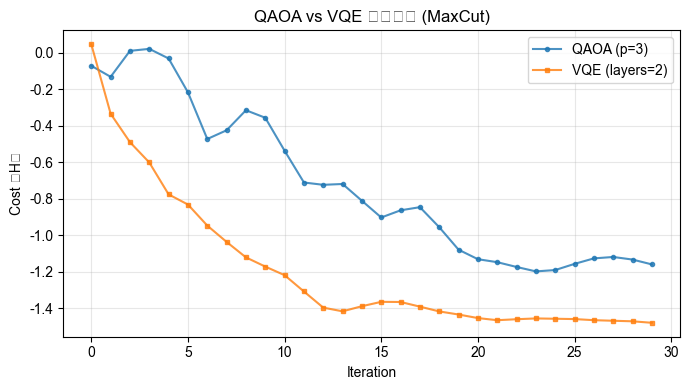

QAOA  最优代价: -1.198556  (params=4)
VQE   最优代价: -1.480609  (params=24)


In [54]:
section("QAOA vs VQE comparison")

# --- 利用 MaxCut 哈密顿量的 Pauli 项作为 VQE 的 custom hamiltonian ---
maxcut_H = build_maxcut_hamiltonian(edges, num_qubits)

# VQE (custom hamiltonian)
client_vqe = QuantumHardwareClient()
vqe_runner = VQERunner(
    client=client_vqe, layers=2, max_iters=max_iters, learning_rate=learning_rate, gradient_method="autograd"
)
result_vqe = vqe_runner.run_model(
    name="vqe_maxcut",
    num_qubits=num_qubits,
    model="custom",
    hamiltonian=maxcut_H,
    prefer_chips="Simulator",
)

# QAOA (reuse the result from part 3)
# result_qaoa 已在前面计算

# --- 对比收敛曲线 ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(result_qaoa.cost_history, "o-", markersize=3, label="QAOA (p=3)", alpha=0.8)
ax.plot(result_vqe.energy_history, "s-", markersize=3, label="VQE (layers=2)", alpha=0.8)
ax.set(xlabel="Iteration", ylabel="Cost ⟨H⟩")
ax.set_title("QAOA vs VQE 收敛对比 (MaxCut)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"QAOA  最优代价: {result_qaoa.best_cost:.6f}  (params={len(result_qaoa.best_params)})")
print(f"VQE   最优代价: {result_vqe.best_energy:.6f}  (params={len(result_vqe.best_params)})")

## 下一步建议

| 方向 | 说明 |
|------|------|
| **增大 p** | QAOA 近似比随层数 p 增大单调提升，可尝试 p=3,4,... |
| **真实硬件** | 将 `provider="simulator"` 替换为 `"quafu"` / `"tianyan"` 等 |
| **Clifford fitting** | 在真机上启用 `clifford_fitting=True` 进行误差缓解 |
| **读出纠错 (ZNE)** | 结合 `quantum_hw.calibration` 中的 zero-noise extrapolation |
| **更大图** | 测试 6-10 qubit 图的 MaxCut，观察扩展性 |
| **自定义混合算符** | 修改 mixer 层为 $e^{-i\beta H_M}$，适配约束优化 |